# LSTM-VAE — Baseline Definitivo v2
## Dataset: SWaT A11 (Feb 2026) + A12 (Mar 2026) | 3 sesiones

### Cambios respecto a Baseline v1

| Aspecto | Baseline v1 | **Baseline v2** |
|---|---|---|
| Datos de entrenamiento | A12 normal (60%) | **A11_d1 + A11_d2 + A12 normal** |
| Filas normales aprox. | ~15,000 | **~50,000** |
| Stride | Optuna (variable) | **5** (= TimeGAN v18) |
| Split | Un CSV, 60/20/20 | **60/20/20 dentro de cada sesion** |
| Val / Test | A12 normal | **Solo A12 normal** |
| Scaler | A12 train | **A11+A12 combined train** |

### Compatibilidad con TimeGAN v18

- `STRIDE = 5` — identico al `TIMEGAN_STRIDE` de v18.
- `WINDOW_SIZE = 60` — sin cambios.
- `continuous_cols` / `discrete_cols` — mismas listas que consume el GAN.
- `scaler_cont.pkl` guardado en `lstm_vae_a12_baseline_v2/` — el GAN v19+
  debe apuntar a este directorio para generar `synth_for_det` compatible.
- Formato ventanas continuas: `(N, T, C)` — LSTM no transpone.
  El GAN genera `synth_all_phys` en `(N, T, C)` y aplica `scaler_cont.transform`;
  ese resultado se usa directamente en este detector sin transponer.

### Protocolo de evaluacion (identico a v1)

- Evaluacion externa con ataques etiquetados de A12.
- Exclusion de IDs sigilosos 1.0 y 2.0 (indetectables con reconstruccion).
- Filtro consecutivo k=3 + sweep de tau para umbral optimo.

### Flujo

```
1. Cargar hiperparametros desde optuna_best_config.json
2. Cargar 3 sesiones (A11_d1, A11_d2, A12 normal)
3. Split 60/20/20 por sesion; train=todo, val/test=solo A12
4. StandardScaler sobre train combinado
5. Ventanas (N,T,C) con stride=5
6. Entrenar LSTM-VAE (max 150 epochs, patience=20)
7. Evaluar con protocolo definitivo (excl. IDs 1,2 | k=3 | sweep tau)
8. Guardar artefactos
```


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# ── Datasets ──────────────────────────────────────────────────────────────────
# A11 (Feb 2026) — solo datos normales, 2 dias de operacion
A11_DIR        = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A11_OTDataset_Feb_26'
RAW_CSV_A11_D1 = A11_DIR / 'SWaT.A10_OTDataset_19-Feb-2026_0930_1735.csv'
RAW_CSV_A11_D2 = A11_DIR / 'SWaT.A10_OTDataset_20-Feb-2026_0905_1710.csv'

# A12 (Mar 2026) — datos normales + ataques etiquetados
RAW_CSV_A12    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'

# ── Modelos ────────────────────────────────────────────────────────────────────
# Columnas e hiperparametros del Optuna LSTM-VAE
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
# Directorio de salida de este detector
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_baseline_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('A11 Day1:', RAW_CSV_A11_D1.exists())
print('A11 Day2:', RAW_CSV_A11_D2.exists())
print('A12 CSV :', RAW_CSV_A12.exists())
print('Optuna  :', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)


A11 Day1: True
A11 Day2: True
A12 CSV : True
Optuna  : True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v2


## 2. Hiperparametros

La arquitectura LSTM-VAE se carga del Optuna v1 (mismo trial #2).
El `STRIDE=5` reemplaza el stride del Optuna para coincidir exactamente
con el `TIMEGAN_STRIDE=5` del GAN v18 — garantiza que ventanas reales
y sinteticas tengan el mismo espaciado temporal.

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
bp              = optuna_cfg['best_params']

# Arquitectura (desde Optuna)
WINDOW_SIZE = 60                # Fijo — igual que TimeGAN v18
STRIDE      = 5                 # = TIMEGAN_STRIDE (reemplaza stride del Optuna)
HIDDEN_SIZE = int(bp['hidden_size'])
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = int(bp['latent_dim'])
DISC_HIDDEN = int(optuna_cfg['disc_hidden'])
BETA        = float(bp['beta'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
LR          = float(bp['lr'])
BATCH_SIZE  = int(bp['batch_size'])

# Pipeline
CLIP_VAL    = float(optuna_cfg['clip_val'])
WARMUP      = 120               # segundos de warmup por sesion
MAX_EPOCHS  = 150
PATIENCE    = 20

# Protocolo de evaluacion definitivo
EXCLUDED_IDS = [1.0, 2.0]       # Ataques sigilosos indetectables
CONSEC_K     = 3                # Filtro de ventanas consecutivas

print(f'Arquitectura : hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}')
print(f'Entrenamiento: beta={BETA:.4f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Pipeline     : window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL} | warmup={WARMUP}s')
print(f'Evaluacion   : excl={EXCLUDED_IDS} | k={CONSEC_K}')
print(f'Columnas     : {len(continuous_cols)} continuas | {len(discrete_cols)} discretas')


Arquitectura : hidden=192 | layers=1 | latent=96
Entrenamiento: beta=0.0161 | alpha=0.8891 | lr=1.07e-04 | batch=64
Pipeline     : window=60 | stride=5 | clip=5.0 | warmup=120s
Evaluacion   : excl=[1.0, 2.0] | k=3
Columnas     : 31 continuas | 31 discretas


## 3. Carga multi-sesion y preprocesamiento

### Sesiones

| Sesion | CSV | Tipo | Tratamiento |
|--------|-----|------|-------------|
| a11_d1 | 19-Feb-2026 | Solo normal | `all_normal=True` — sin columna attack_label |
| a11_d2 | 20-Feb-2026 | Solo normal | `all_normal=True` — sin columna attack_label |
| a12    | 11-Mar-2026 | Normal + ataques | Filtrar `attack_label==0` |

### Split 60/20/20 dentro de cada sesion

El split se aplica **por separado en cada sesion** para evitar ventanas que
crucen el limite entre sesiones. Luego:
- **Train**: los 60% de las 3 sesiones concatenados.
- **Val / Test**: **solo A12** (distribucion objetivo con ataques etiquetados).

In [5]:
all_sensor_cols = feature_cols  # = continuous_cols + discrete_cols

def load_normal_session(path, all_normal=False):
    """Carga CSV de SWaT, limpia tipos mixtos y retorna solo filas normales.

    Args:
        path      : ruta al CSV.
        all_normal: True para A11 (sin columnas de ataque, todo es normal).
                    False para A12 (tiene attack_label; se filtra ==0).
    Returns:
        DataFrame con t_stamp + all_sensor_cols, solo filas normales.
    """
    df = pd.read_csv(path, low_memory=False)
    df['t_stamp'] = pd.to_datetime(df['t_stamp'], errors='coerce')
    df = df.sort_values('t_stamp').reset_index(drop=True)
    for col in all_sensor_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('Bad Input', np.nan), errors='coerce')
    if all_normal:
        df['attack_label'] = 0
    else:
        df['attack_label'] = pd.to_numeric(df['attack_label'], errors='coerce').fillna(0).astype(int)
    df_normal = df[df['attack_label'] == 0][['t_stamp'] + all_sensor_cols].copy()
    return df_normal.reset_index(drop=True)

# Cargar las 3 sesiones y aplicar warmup individual
print('Cargando sesiones...')
sessions_raw = {
    'a11_d1': load_normal_session(RAW_CSV_A11_D1, all_normal=True),
    'a11_d2': load_normal_session(RAW_CSV_A11_D2, all_normal=True),
    'a12'   : load_normal_session(RAW_CSV_A12,    all_normal=False),
}

sessions_normal = {}
for name, df_s in sessions_raw.items():
    t0   = df_s['t_stamp'].min()
    df_w = df_s[df_s['t_stamp'] >= t0 + pd.Timedelta(seconds=WARMUP)].copy().reset_index(drop=True)
    sessions_normal[name] = df_w
    print(f'  {name}: {len(df_w):,} filas | {df_w["t_stamp"].min()} -> {df_w["t_stamp"].max()}')

total = sum(len(v) for v in sessions_normal.values())
print(f'\nTotal normal (3 sesiones): {total:,}')
print(f'  A11 d1+d2: {len(sessions_normal["a11_d1"])+len(sessions_normal["a11_d2"]):,}')
print(f'  A12:       {len(sessions_normal["a12"]):,}')


Cargando sesiones...
  a11_d1: 29,040 filas | 2026-02-19 09:32:00 -> 2026-02-19 17:35:59
  a11_d2: 29,040 filas | 2026-02-20 09:07:00 -> 2026-02-20 17:10:59
  a12: 25,620 filas | 2026-03-11 09:02:00 -> 2026-03-11 17:00:59

Total normal (3 sesiones): 83,700
  A11 d1+d2: 58,080
  A12:       25,620


In [6]:
# Split 60/20/20 dentro de cada sesion por separado
session_splits = {}
for name, df_s in sessions_normal.items():
    n = len(df_s)
    t1, t2 = int(n*0.60), int(n*0.80)
    session_splits[name] = {
        'train': df_s.iloc[:t1].copy().reset_index(drop=True),
        'val'  : df_s.iloc[t1:t2].copy().reset_index(drop=True),
        'test' : df_s.iloc[t2:].copy().reset_index(drop=True),
    }
    print(f'{name}: train={t1:,} | val={t2-t1:,} | test={n-t2:,}')

# Train = las 3 sesiones concatenadas
df_train = pd.concat([session_splits[k]['train'] for k in session_splits],
                     ignore_index=True)
# Val / Test = SOLO A12
df_val   = session_splits['a12']['val'].copy()
df_test  = session_splits['a12']['test'].copy()

print(f'\nTrain combinado (3 sesiones): {len(df_train):,}')
print(f'Val   (solo A12)            : {len(df_val):,}')
print(f'Test  (solo A12)            : {len(df_test):,}')

# Imputar NaN con moda del train combinado
modes_train = df_train[all_sensor_cols].mode().iloc[0]
for df_ in [df_train, df_val, df_test]:
    df_[all_sensor_cols] = df_[all_sensor_cols].fillna(modes_train)
for name in session_splits:
    for split in ['train','val','test']:
        session_splits[name][split][all_sensor_cols] = \
            session_splits[name][split][all_sensor_cols].fillna(modes_train)

print(f'NaN tras imputacion: {df_train[all_sensor_cols].isna().sum().sum()}')


a11_d1: train=17,424 | val=5,808 | test=5,808
a11_d2: train=17,424 | val=5,808 | test=5,808
a12: train=15,372 | val=5,124 | test=5,124

Train combinado (3 sesiones): 50,220
Val   (solo A12)            : 5,124
Test  (solo A12)            : 5,124
NaN tras imputacion: 0


## 4. Escalado

**StandardScaler** fiteado en el train combinado A11+A12.
Cubre el rango completo de operacion del sistema en multiples dias y
condiciones, reduciendo la probabilidad de que el detector asigne scores
altos a variaciones normales que solo aparecen en A11.

> **Nota de compatibilidad TimeGAN:** este `scaler_cont.pkl` debe ser el que
> usa el GAN v19+ para generar `synth_for_det`. Si el GAN sigue apuntando
> al scaler de `conv1d_hybrid_a12_v6`, los sinteticos deben re-escalarse
> antes de pasarlos a este detector.

In [7]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values), -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

# Tambien escalar por sesion para construccion de ventanas
session_train_sc = {name: scale_df(session_splits[name]['train'])
                    for name in session_splits}

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

rng = df_train_sc[continuous_cols].values.min(), df_train_sc[continuous_cols].values.max()
print(f'Train cont tras clip [{CLIP_VAL}]: [{rng[0]:.2f}, {rng[1]:.2f}]')
print(f'Scaler guardado en: {SAVE_DIR / "scaler_cont.pkl"}')


Train cont tras clip [5.0]: [-5.00, 5.00]
Scaler guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v2\scaler_cont.pkl


## 5. Ventanas de entrenamiento

Forma `(N, T, C)` para LSTM. `STRIDE=5` = `TIMEGAN_STRIDE`.
Las ventanas se construyen **por sesion por separado** antes de concatenar
para evitar ventanas que crucen limites de sesion.

In [8]:
def create_windows(arr, ws, stride):
    """Ventanas deslizantes. Retorna (N, ws, C) — formato LSTM."""
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    """Summary stats por ventana para variables discretas."""
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

# Construir ventanas de entrenamiento POR SESION
train_wins_c_list, train_wins_d_list = [], []
for name in session_splits:
    df_s = session_train_sc[name]
    wc = create_windows(df_s[continuous_cols].values.astype(np.float32), WINDOW_SIZE, STRIDE)
    wd = create_windows(df_s[discrete_cols].values.astype(np.float32),   WINDOW_SIZE, STRIDE)
    wds= summarize_discrete_windows(wd, discrete_cols).values.astype(np.float32)
    train_wins_c_list.append(wc)
    train_wins_d_list.append(wds)
    print(f'  {name} train: {len(df_s):,} filas -> {wc.shape[0]:,} ventanas')

X_tr_c = np.concatenate(train_wins_c_list, axis=0)
X_tr_d = np.concatenate(train_wins_d_list, axis=0)

# Val y Test: solo A12
def build_windows_pair(df_sc, ws, stride):
    wc  = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, discrete_cols).values.astype(np.float32)
    return wc, wds

X_va_c, X_va_d = build_windows_pair(df_val_sc,  WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_pair(df_test_sc, WINDOW_SIZE, STRIDE)

print(f'\nTrain: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}')
print(f'Total ventanas train: {len(X_tr_c):,} ({len(X_tr_c)/len(session_splits)/1000:.1f}k por sesion promedio)')


  a11_d1 train: 17,424 filas -> 3,473 ventanas
  a11_d2 train: 17,424 filas -> 3,473 ventanas
  a12 train: 15,372 filas -> 3,063 ventanas

Train: (10009, 60, 31)  (N, T, C)
Val  : (1013, 60, 31)
Test : (1013, 60, 31)
Disc summary dim: 124
Total ventanas train: 10,009 (3.3k por sesion promedio)


## 6. Arquitectura LSTM-VAE Hibrido

```
Continuas (N,T,C) --> LSTMEncoder --> mu, logvar --> z
                                                      |
                                                      v
                                             LSTMDecoder --> x_hat (N,T,C)

Discretas (N,D) ---> MLPEncoder --> h_d --> MLPDecoder --> xd_hat
```
**Perdida (ELBO):** `L = alpha*(MSE_cont + beta*KL) + (1-alpha)*MSE_disc`

**Score:** `alpha*MSE_cont + (1-alpha)*MSE_disc`  (KL solo en train)

In [9]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    cont_size   = X_tr_c.shape[2],
    seq_len     = WINDOW_SIZE,
    disc_dim    = X_tr_d.shape[1],
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales : {n_params:,}')
print(f'  Encoder LSTM     : {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM     : {sum(p.numel() for p in model.decoder_cont.parameters()):,}')
print(f'  Encoder disc     : {sum(p.numel() for p in model.encoder_disc.parameters()):,}')
print(f'  Decoder disc     : {sum(p.numel() for p in model.decoder_disc.parameters()):,}')


Parametros totales : 477,435
  Encoder LSTM     : 209,856
  Decoder LSTM     : 247,327
  Encoder disc     : 10,080
  Decoder disc     : 10,172


## 7. Entrenamiento

In [10]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist, hist_mse_c, hist_mse_d, hist_kl = [], [], [], [], []

print(f'Batch:{BATCH_SIZE} | LR:{LR:.2e} | MaxEp:{MAX_EPOCHS} | Patience:{PATIENCE}')
print(f'beta={BETA:.4f} | alpha={ALPHA:.4f}')
print(f'Train batches/epoca: {len(train_loader)}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb_b = len(train_loader)
    tl /= nb_b; tmse_c /= nb_b; tmse_d /= nb_b; tkl /= nb_b

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        best_ep  = epoch
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} '
              f'(mse_c={tmse_c:.4f} kl={tkl:.4f}) | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.')
        break

model.load_state_dict(best_wts)
model.eval()
print(f'\nMejor val:{best_val:.5f} ep{best_ep}')


Batch:64 | LR:1.07e-04 | MaxEp:150 | Patience:20
beta=0.0161 | alpha=0.8891
Train batches/epoca: 156
Ep   10/150 | Train:0.08873 (mse_c=0.0828 kl=0.8474) | Val:0.16169 | Best:0.16089(ep9)
Ep   20/150 | Train:0.06569 (mse_c=0.0594 kl=0.7721) | Val:0.14477 | Best:0.14212(ep19)
Ep   30/150 | Train:0.05745 (mse_c=0.0521 kl=0.6937) | Val:0.13875 | Best:0.13740(ep28)
Ep   40/150 | Train:0.05318 (mse_c=0.0484 kl=0.6406) | Val:0.12776 | Best:0.12776(ep40)
Ep   50/150 | Train:0.05049 (mse_c=0.0465 kl=0.5878) | Val:0.13270 | Best:0.12637(ep41)
Ep   60/150 | Train:0.04799 (mse_c=0.0442 kl=0.5643) | Val:0.13398 | Best:0.12637(ep41)
Early stop ep61.

Mejor val:0.12637 ep41


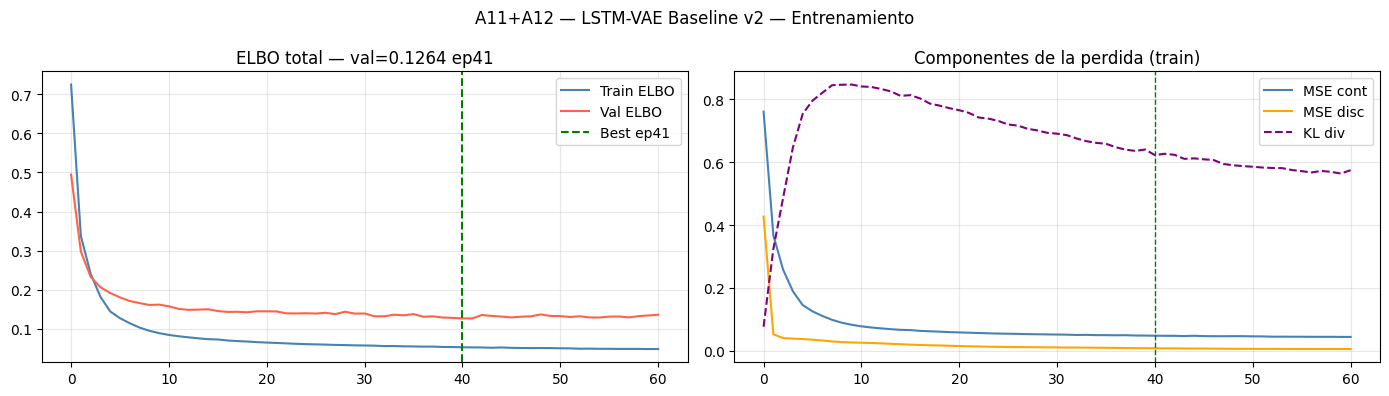

In [11]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO total — val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('A11+A12 — LSTM-VAE Baseline v2 — Entrenamiento', fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 8. Evaluacion con protocolo definitivo

### 8a. Ventanas de evaluacion con metadatos de ataque

Se escala todo el CSV de A12 (normales + ataques) con el scaler nuevo
y se construyen ventanas con metadatos por ventana (`attack_id`, `attack_name`).

In [12]:
# Cargar A12 completo (con ataques) para evaluacion externa
df_a12_full = pd.read_csv(RAW_CSV_A12, low_memory=False)
df_a12_full['t_stamp']      = pd.to_datetime(df_a12_full['t_stamp'], errors='coerce')
df_a12_full['attack_label'] = pd.to_numeric(df_a12_full['attack_label'], errors='coerce').fillna(0).astype(int)
df_a12_full = df_a12_full.sort_values('t_stamp').reset_index(drop=True)

for col in all_sensor_cols:
    if col in df_a12_full.columns:
        df_a12_full[col] = pd.to_numeric(
            df_a12_full[col].replace('Bad Input', np.nan), errors='coerce'
        )

meta_cols_avail = [c for c in ['attack_id','attack_name','attack_targets'] if c in df_a12_full.columns]
df_a12_full[all_sensor_cols] = df_a12_full[all_sensor_cols].fillna(modes_train)

# Escalar con scaler nuevo (A11+A12)
df_eval_sc = df_a12_full[['t_stamp','attack_label'] + all_sensor_cols].copy()
df_eval_sc[continuous_cols] = np.clip(
    scaler_cont.transform(df_eval_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[discrete_cols] = (df_eval_sc[discrete_cols] / disc_max).clip(0, 1)

# Arrays
cont_arr   = df_eval_sc[continuous_cols].values.astype(np.float32)
disc_arr   = df_eval_sc[discrete_cols].values.astype(np.float32)
labs_arr   = df_eval_sc['attack_label'].values
tstamp_arr = df_eval_sc['t_stamp'].values
aid_arr    = df_a12_full['attack_id'].values   if 'attack_id'   in df_a12_full.columns else np.zeros(len(df_a12_full))
aname_arr  = df_a12_full['attack_name'].values if 'attack_name' in df_a12_full.columns else np.full(len(df_a12_full),'unknown')

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs==1]
    atk_nms  = seg_anms[seg_labs==1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_name': str(anm_mode), 't_start': tstamp_arr[s],
                      'attack_frac': float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)

print(f'Ventanas eval (A12): {len(df_wins):,}')
print(f'  Normal (y=0)     : {(df_wins["y"]==0).sum():,}')
print(f'  Ataque (y=1)     : {(df_wins["y"]==1).sum():,}  ({100*df_wins["y"].mean():.1f}%)')
print(f'  Tipos de ataque  : {df_wins[df_wins["y"]==1]["attack_id"].nunique()}')


Ventanas eval (A12): 5,761
  Normal (y=0)     : 5,027
  Ataque (y=1)     : 734  (12.7%)
  Tipos de ataque  : 11


### 8b. Computo de scores y distribucion de referencia

[REFERENCIA — todos los ataques]
Error medio NORMAL: 0.0652
Error medio ATAQUE: 0.1668  (ratio: 2.56x)
ROC-AUC referencia (todos ataques): 0.7529


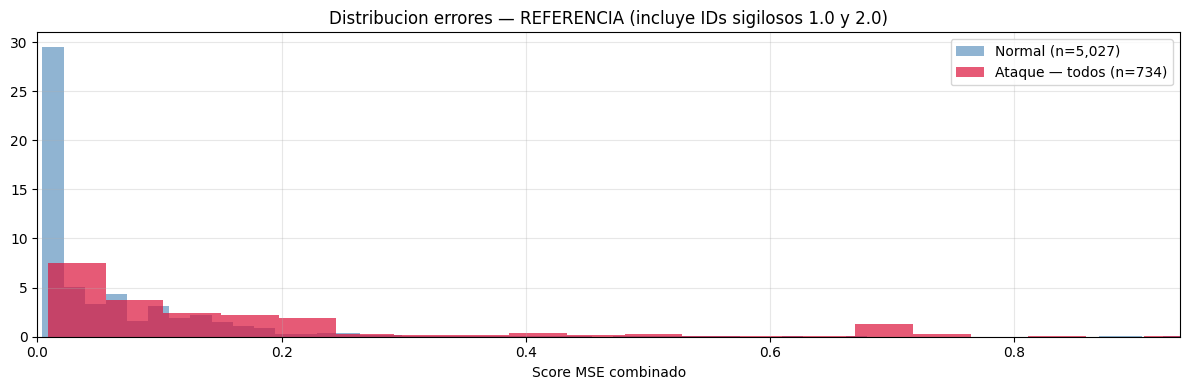

In [13]:
def recon_scores(model, Xc, Xd, alpha, bs=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores   = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores
y_all    = df_wins['y'].values

mn_all = scores[y_all==0].mean(); ma_all = scores[y_all==1].mean()
print(f'[REFERENCIA — todos los ataques]')
print(f'Error medio NORMAL: {mn_all:.4f}')
print(f'Error medio ATAQUE: {ma_all:.4f}  (ratio: {ma_all/mn_all:.2f}x)')

auc_ref = roc_auc_score(y_all, scores)
print(f'ROC-AUC referencia (todos ataques): {auc_ref:.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_all==0], bins=80, alpha=0.6, density=True, color='steelblue',
        label=f'Normal (n={(y_all==0).sum():,})')
ax.hist(scores[y_all==1], bins=40, alpha=0.7, density=True, color='crimson',
        label=f'Ataque — todos (n={(y_all==1).sum():,})')
ax.set_xlabel('Score MSE combinado')
ax.set_title('Distribucion errores — REFERENCIA (incluye IDs sigilosos 1.0 y 2.0)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_referencia.png'), dpi=120, bbox_inches='tight')
plt.show()


### 8c. Protocolo definitivo: exclusion + sweep tau + metricas

**Paso 1** — Excluir IDs sigilosos 1.0 y 2.0.

**Paso 2** — Sweep de tau con filtro consecutivo k=3.

**Paso 3** — Metricas finales y tabla por tipo de ataque.

In [14]:
# Paso 1: excluir ataques sigilosos
mask_keep = ~((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS)))
df_filt   = df_wins[mask_keep].copy().reset_index(drop=True)
sc_filt   = scores[mask_keep.values]
y_filt    = df_filt['y'].values

print(f'Excluidas : {(~mask_keep).sum()} ventanas (IDs {EXCLUDED_IDS})')
print(f'Eval      : {len(df_filt):,} ventanas | Normal: {(y_filt==0).sum():,} | Ataque: {(y_filt==1).sum():,}')
print()
print('Tipos de ataque evaluados:')
for aid, grp in df_filt[df_filt['y']==1].groupby('attack_id'):
    print(f'  ID {aid:.0f}: {grp["attack_name"].mode().iloc[0][:45]}  ({len(grp)} ventanas)')


Excluidas : 142 ventanas (IDs [1.0, 2.0])
Eval      : 5,619 ventanas | Normal: 5,027 | Ataque: 592

Tipos de ataque evaluados:
  ID 3: Florida Water Plant Scenario — Dosing Pump Ac  (71 ventanas)
  ID 4: Tank Overflow via LIT101 Spoofing — Schneider  (71 ventanas)
  ID 5: Stage 5 Valve Manipulation — MV503/504 Open,   (71 ventanas)
  ID 6: Tank Overflow via LIT101 Spoofing — Schneider  (30 ventanas)
  ID 7: Stage 2 Parallel Pump Override — MV201 Open,   (65 ventanas)
  ID 8: Reverse Osmosis Backwash Diversion — MV302 Cl  (71 ventanas)
  ID 9: Forced Backwash Trigger via DPIT301 Spoofing   (71 ventanas)
  ID 10: Multi-Value Level Oscillation — LIT601 Spoofi  (71 ventanas)
  ID 11: AIT402 High-Value Spoof Start – Using script  (71 ventanas)


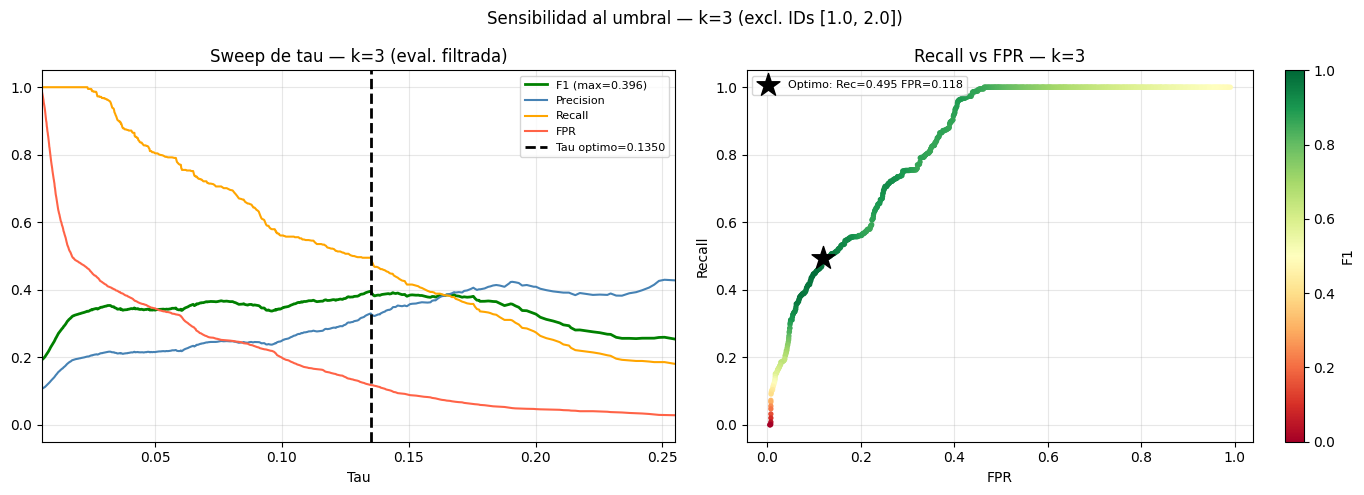

Tau optimo: 0.1350


In [15]:
# Paso 2: sweep de tau con k=CONSEC_K
def consecutive_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for i in range(k-1, len(raw)):
        out[i] = int(raw[i-k+1:i+1].all())
    return out

taus   = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []
for tau in taus:
    pred = consecutive_filter(sc_filt, tau, CONSEC_K)
    tp = ((pred==1)&(y_filt==1)).sum(); fp = ((pred==1)&(y_filt==0)).sum()
    fn = ((pred==0)&(y_filt==1)).sum(); tn = ((pred==0)&(y_filt==0)).sum()
    p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
    sw_f1.append(2*p*r/(p+r+1e-10))
    sw_prec.append(p); sw_rec.append(r); sw_fpr.append(fp/(fp+tn+1e-10))

sw_f1    = np.array(sw_f1)
best_idx = sw_f1.argmax()
TAU_OPT  = float(taus[best_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(taus, sw_f1,   color='green',     lw=2,   label=f'F1 (max={sw_f1.max():.3f})')
axes[0].plot(taus, sw_prec, color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus, sw_rec,  color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus, sw_fpr,  color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(TAU_OPT, color='black', lw=2, linestyle='--', label=f'Tau optimo={TAU_OPT:.4f}')
axes[0].set_xlabel('Tau'); axes[0].set_xlim(taus[0], np.percentile(sc_filt, 95))
axes[0].set_title(f'Sweep de tau — k={CONSEC_K} (eval. filtrada)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=3)
axes[1].scatter(sw_fpr[best_idx], sw_rec[best_idx], marker='*', s=300, color='black', zorder=5,
                label=f'Optimo: Rec={sw_rec[best_idx]:.3f} FPR={sw_fpr[best_idx]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title(f'Recall vs FPR — k={CONSEC_K}')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle(f'Sensibilidad al umbral — k={CONSEC_K} (excl. IDs {EXCLUDED_IDS})', fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'tau_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Tau optimo: {TAU_OPT:.4f}')


In [16]:
# Paso 3: metricas finales
pred_final = consecutive_filter(sc_filt, TAU_OPT, CONSEC_K)
tp = int(((pred_final==1)&(y_filt==1)).sum())
fp = int(((pred_final==1)&(y_filt==0)).sum())
fn = int(((pred_final==0)&(y_filt==1)).sum())
tn = int(((pred_final==0)&(y_filt==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc_filt    = roc_auc_score(y_filt, sc_filt)
pr_auc_filt = average_precision_score(y_filt, sc_filt)

print('=' * 65)
print('METRICAS BASELINE v2 — A11+A12 | stride=5')
print('=' * 65)
print(f'  Protocolo    : excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | tau={TAU_OPT:.4f}')
print()
print(f'  ROC-AUC  : {auc_filt:.4f}   PR-AUC  : {pr_auc_filt:.4f}')
print(f'  F1       : {f1:.3f}     Recall  : {rec:.3f}')
print(f'  Precision: {prec:.3f}     FPR     : {fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print()
print(f'  [Ref. sin filtro] ROC-AUC: {auc_ref:.4f}')
print('=' * 65)


METRICAS BASELINE v2 — A11+A12 | stride=5
  Protocolo    : excl. IDs [1.0, 2.0] | k=3 | tau=0.1350

  ROC-AUC  : 0.8252   PR-AUC  : 0.3201
  F1       : 0.396     Recall  : 0.495
  Precision: 0.330     FPR     : 0.118
  TP=293 | FP=595 | FN=299 | TN=4432

  [Ref. sin filtro] ROC-AUC: 0.7529


### 8d. Graficos de evaluacion

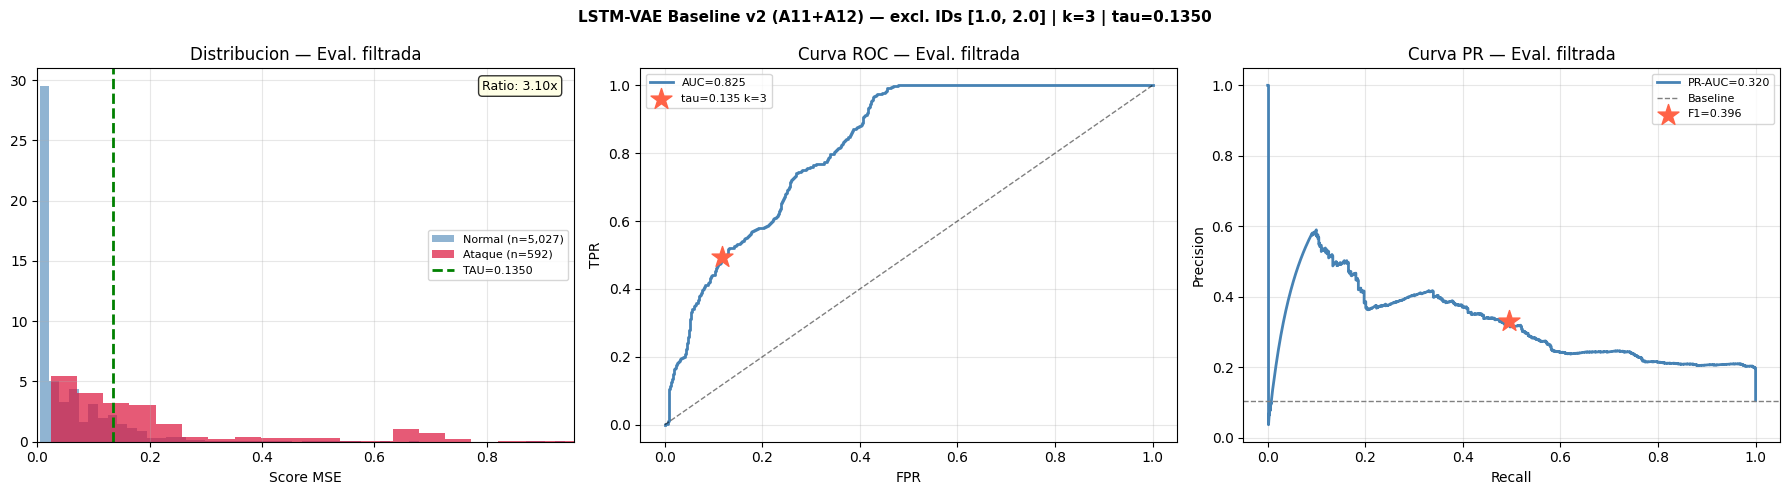

In [17]:
# Distribucion filtrada + ROC + PR
fprs_c, tprs_c, _ = roc_curve(y_filt, sc_filt)
precs_c, recs_c, _ = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mn_f = sc_filt[y_filt==0].mean(); ma_f = sc_filt[y_filt==1].mean()
axes[0].hist(sc_filt[y_filt==0], bins=80, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={(y_filt==0).sum():,})')
axes[0].hist(sc_filt[y_filt==1], bins=40, alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={(y_filt==1).sum():,})')
axes[0].axvline(TAU_OPT, color='green', lw=2, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].text(0.97, 0.97, f'Ratio: {ma_f/mn_f:.2f}x', ha='right', va='top',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)
axes[0].set_xlabel('Score MSE'); axes[0].set_title('Distribucion — Eval. filtrada')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

axes[1].plot(fprs_c, tprs_c, color='steelblue', lw=2, label=f'AUC={auc_filt:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].scatter(fpr, rec, marker='*', s=250, color='tomato', zorder=5,
                label=f'tau={TAU_OPT:.3f} k={CONSEC_K}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — Eval. filtrada')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(recs_c, precs_c, color='steelblue', lw=2, label=f'PR-AUC={pr_auc_filt:.3f}')
axes[2].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].scatter(rec, prec, marker='*', s=250, color='tomato', zorder=5, label=f'F1={f1:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Curva PR — Eval. filtrada')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'LSTM-VAE Baseline v2 (A11+A12) — excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | tau={TAU_OPT:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'eval_dist_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()


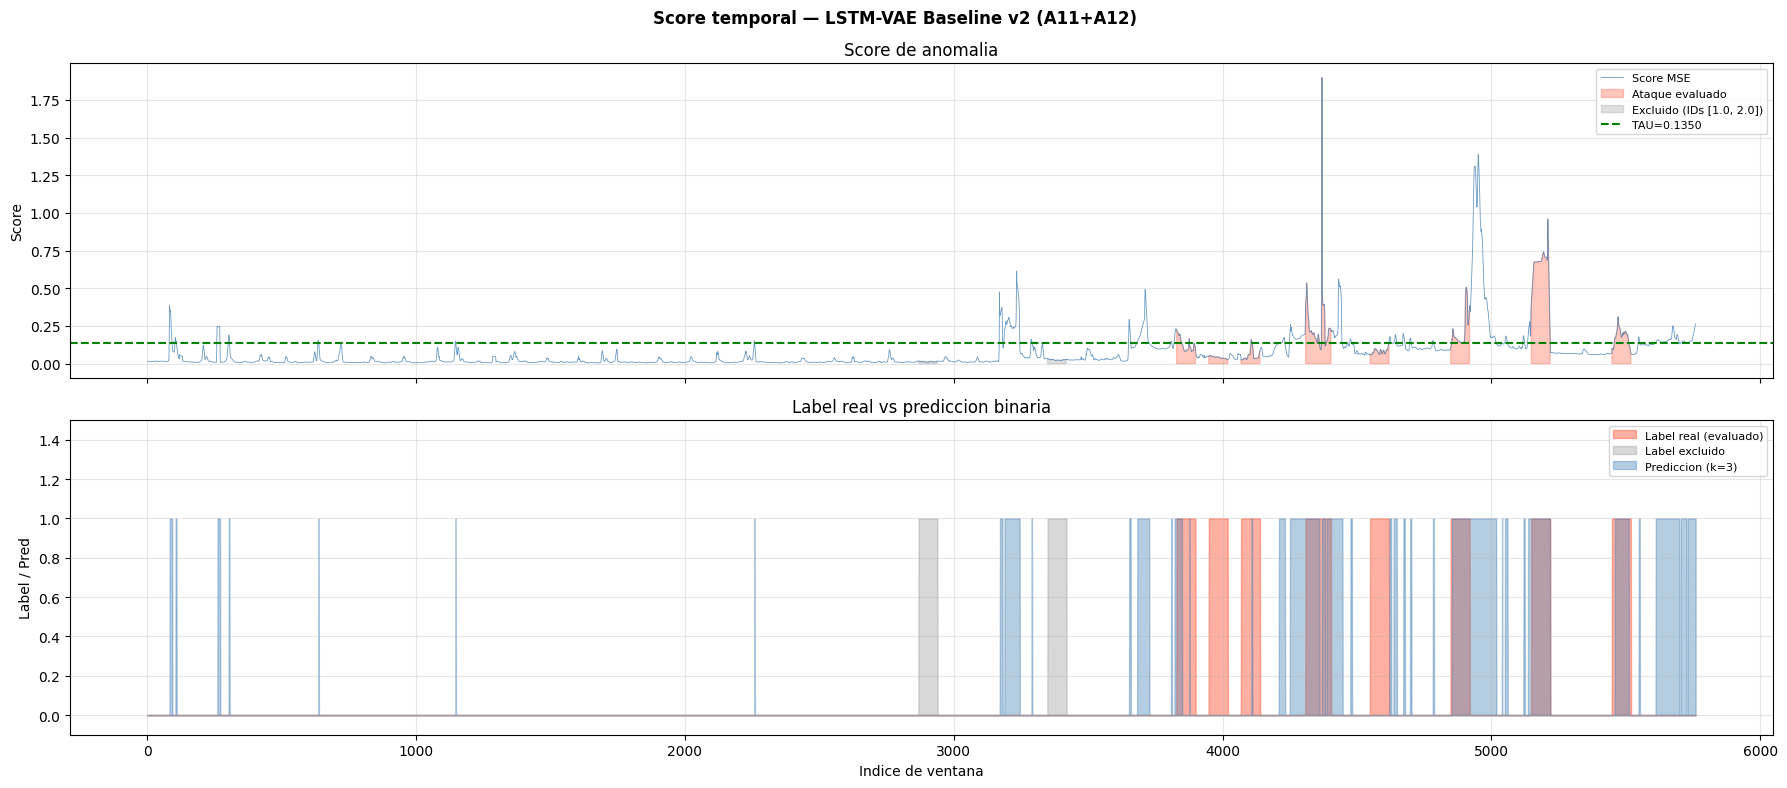

In [18]:
# Score temporal
t = np.arange(len(df_wins))
pred_all_k = consecutive_filter(scores, TAU_OPT, CONSEC_K)
excl_mask  = ((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS))).values

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
axes[0].plot(t, scores, color='steelblue', lw=0.6, alpha=0.8, label='Score MSE')
axes[0].fill_between(t, 0, scores, where=(y_all==1) & ~excl_mask,
                     color='tomato', alpha=0.35, label='Ataque evaluado')
axes[0].fill_between(t, 0, scores, where=excl_mask,
                     color='gray', alpha=0.25, label=f'Excluido (IDs {EXCLUDED_IDS})')
axes[0].axhline(TAU_OPT, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_ylabel('Score'); axes[0].set_title('Score de anomalia')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(t, 0, y_all.astype(float) * ~excl_mask,
                     color='tomato', alpha=0.5, label='Label real (evaluado)')
axes[1].fill_between(t, 0, excl_mask.astype(float),
                     color='gray', alpha=0.3, label='Label excluido')
axes[1].fill_between(t, 0, pred_all_k.astype(float),
                     color='steelblue', alpha=0.4, label=f'Prediccion (k={CONSEC_K})')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Label / Pred')
axes[1].set_title('Label real vs prediccion binaria')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Score temporal — LSTM-VAE Baseline v2 (A11+A12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'score_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()


In [19]:
# Tabla de deteccion por tipo de ataque
print('Deteccion por tipo de ataque (tau optimo, k=3):')
print(f'{"ID":>5}  {"Nombre":45}  {"Ventanas":>8}  {"Det. (%)": >12}  {"Score med.":>10}')
print('-' * 90)
for aid, grp in df_wins[df_wins['y']==1].sort_values('attack_id').groupby('attack_id'):
    n_tot   = len(grp)
    pred_g  = consecutive_filter(grp['score'].values, TAU_OPT, CONSEC_K)
    n_det   = int(pred_g.sum())
    excl    = aid in EXCLUDED_IDS
    tag     = '  [EXCLUIDO]' if excl else ''
    name    = grp['attack_name'].mode().iloc[0][:43]
    print(f'{aid:>5.0f}  {name:45}  {n_tot:>8}  {n_det:>6} ({100*n_det/n_tot:5.1f}%)  '
          f'{grp["score"].mean():>10.4f}{tag}')


Deteccion por tipo de ataque (tau optimo, k=3):
   ID  Nombre                                         Ventanas      Det. (%)  Score med.
------------------------------------------------------------------------------------------
    1  Stage 5 Valve Manipulation — MV503/504 Open          71       0 (  0.0%)      0.0131  [EXCLUIDO]
    2  Stage 1 Flow Disruption — MV101 Open, P101           71       0 (  0.0%)      0.0252  [EXCLUIDO]
    3  Florida Water Plant Scenario — Dosing Pump           71      20 ( 28.2%)      0.1273
    4  Tank Overflow via LIT101 Spoofing — Schneid          71       0 (  0.0%)      0.0413
    5  Stage 5 Valve Manipulation — MV503/504 Open          71       3 (  4.2%)      0.0540
    6  Tank Overflow via LIT101 Spoofing — Schneid          30      28 ( 93.3%)      0.2920
    7  Stage 2 Parallel Pump Override — MV201 Open          65      48 ( 73.8%)      0.2342
    8  Reverse Osmosis Backwash Diversion — MV302           71       0 (  0.0%)      0.0810
    9  Force

## 9. Guardar artefactos

In [20]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_all==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['optimal_filtered'] = TAU_OPT
with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': continuous_cols,
               'discrete_cols':   discrete_cols,
               'feature_cols':    feature_cols}, f, indent=4)

config = {
    'version'         : 'lstm_vae_a12_baseline_v2',
    'dataset_train'   : 'SWaT A11 (Feb 2026, 2 dias) + A12 (Mar 2026, normal only)',
    'dataset_eval'    : 'SWaT A12 (Mar 2026, normal + ataques)',
    'architecture'    : 'LSTM-VAE Hybrid (Optuna trial #2)',
    'optuna_source'   : 'lstm_vae_a12_optuna_v1 / trial #2',
    'split'           : 'chronological_60_20_20_per_session; val+test=only_A12',
    'sessions'        : ['a11_d1 (19-Feb-2026)', 'a11_d2 (20-Feb-2026)', 'a12 (11-Mar-2026)'],
    'window_size'     : WINDOW_SIZE,
    'stride'          : STRIDE,
    'clip_val'        : CLIP_VAL,
    'warmup_sec'      : WARMUP,
    'score_formula'   : 'alpha*MSE_cont + (1-alpha)*MSE_disc  [KL solo en train]',
    'timegan_compat'  : {
        'timegan_version' : 'v18',
        'stride_match'    : True,
        'window_size_match': True,
        'scaler_note'     : (
            'Este scaler_cont.pkl esta fiteado en A11+A12 combined train. '
            'El GAN v19+ debe apuntar a lstm_vae_a12_baseline_v2/scaler_cont.pkl '
            'para que synth_for_det sea compatible con este detector. '
            'Si el GAN sigue usando conv1d_hybrid_a12_v6/scaler_cont.pkl, '
            'aplicar re-escalado antes de inferencia.'
        ),
        'synth_format'    : '(N, T, C) — NO transponer para LSTM-VAE',
    },
    'model_params'    : {
        'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
        'latent_dim' : LATENT_DIM,  'disc_hidden': DISC_HIDDEN,
        'alpha'      : float(ALPHA),'beta': float(BETA),
        'dropout'    : float(DROPOUT),'lr': float(LR), 'batch_size': BATCH_SIZE,
    },
    'training'        : {'best_epoch': best_ep, 'best_val_loss': float(best_val),
                         'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
                         'n_windows_train': int(len(X_tr_c))},
    'eval_protocol'   : {
        'excluded_attack_ids': EXCLUDED_IDS,
        'exclusion_reason'   : (
            'Ataques fisicos sigilosos dentro del envelope estadistico normal. '
            'Indetectables con reconstruccion no supervisada '
            '[Taormina et al. 2018; Goh et al. 2017].'
        ),
        'consecutive_k'      : CONSEC_K,
        'tau_optimal'        : TAU_OPT,
    },
    'metrics_reference': {'roc_auc': float(auc_ref)},
    'metrics_baseline' : {
        'roc_auc'   : float(auc_filt), 'pr_auc'    : float(pr_auc_filt),
        'f1'        : float(f1),       'recall'    : float(rec),
        'precision' : float(prec),     'fpr'       : float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    },
    'continuous_cols' : continuous_cols,
    'discrete_cols'   : discrete_cols,
    'feature_cols'    : feature_cols,
    'scenarios'       : ['real_only', 'synthetic_only', 'real_plus_synthetic'],
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp_ in sorted(SAVE_DIR.iterdir()): print(f'  {fp_.name}')
print()
print('=== RESUMEN FINAL ===')
print(f'  ROC-AUC   : {auc_filt:.4f}  |  PR-AUC    : {pr_auc_filt:.4f}')
print(f'  F1        : {f1:.3f}   |  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}   |  FPR       : {fpr:.3f}')
print(f'  tau optimo: {TAU_OPT:.4f}  |  k         : {CONSEC_K}')
print(f'  Excluidos : IDs {EXCLUDED_IDS}')
print(f'  Train     : {len(X_tr_c):,} ventanas (A11_d1 + A11_d2 + A12 normal, stride={STRIDE})')


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v2
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png

=== RESUMEN FINAL ===
  ROC-AUC   : 0.8252  |  PR-AUC    : 0.3201
  F1        : 0.396   |  Recall    : 0.495
  Precision : 0.330   |  FPR       : 0.118
  tau optimo: 0.1350  |  k         : 3
  Excluidos : IDs [1.0, 2.0]
  Train     : 10,009 ventanas (A11_d1 + A11_d2 + A12 normal, stride=5)
